findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

【中英文肌肉对照表】
 GMax = 臀大肌
 RF   = 股直肌
 BF   = 股二头肌
 GM   = 腓肠肌内侧
 TA   = 胫骨前肌


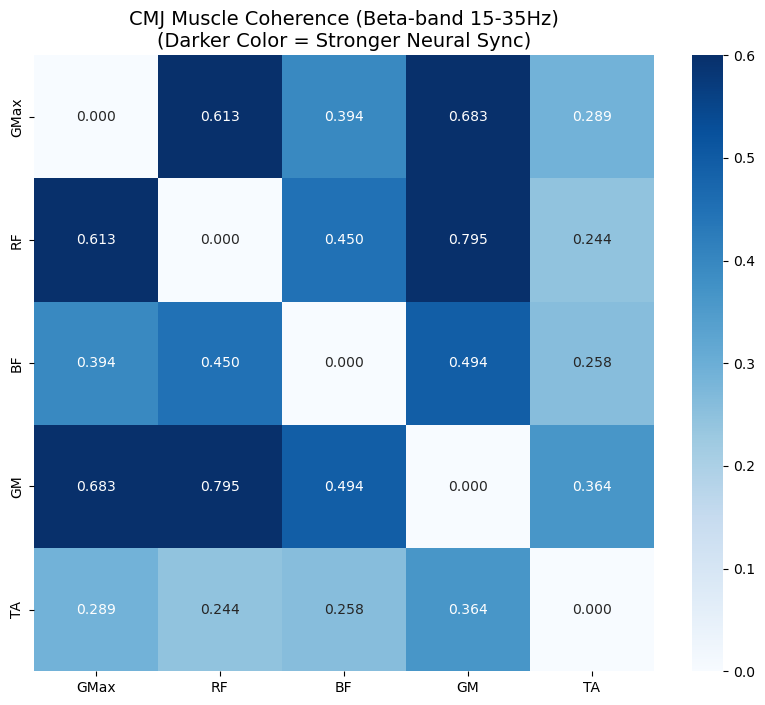


=== 神经相干性具体数值 ===
        GMax      RF      BF      GM      TA
GMax  0.0000  0.6127  0.3943  0.6830  0.2894
RF    0.6127  0.0000  0.4499  0.7950  0.2441
BF    0.3943  0.4499  0.0000  0.4936  0.2583
GM    0.6830  0.7950  0.4936  0.0000  0.3638
TA    0.2894  0.2441  0.2583  0.3638  0.0000


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

# ==========================================
# 1. 模拟数据生成 (保持不变)
# ==========================================
np.random.seed(42)
fs = 1000
duration = 1.0 
t = np.linspace(0, duration, int(fs*duration))

# 肌肉英文缩写 (画图用这个，不会报错)
muscles = ['GMax', 'RF', 'BF', 'GM', 'TA']

# 构造数据
common_drive = 0.6 * np.sin(2 * np.pi * 20 * t) # Beta波模拟

data = {}
for m in muscles:
    noise = np.random.normal(0, 1, len(t))
    burst = np.exp(-((t - 0.5)**2) / (2 * 0.15**2))
    
    # 假设 臀大肌(GMax)、股直肌(RF)、腓肠肌(GM) 协同很好
    if m in ['GMax', 'RF', 'GM']: 
        sig = (burst + common_drive) * noise 
    else: 
        sig = burst * 0.3 * noise
    data[m] = sig

df = pd.DataFrame(data)

# ==========================================
# 2. 核心分析函数 (保持不变)
# ==========================================

def analyze_cmj_coherence(df, fs):
    muscle_list = df.columns.tolist()
    n = len(muscle_list)
    coh_matrix = np.zeros((n, n))
    
    # 预处理
    b, a = signal.butter(4, [20/500, 450/500], btype='band')
    rectified_data = {}
    for m in muscle_list:
        clean_sig = signal.filtfilt(b, a, df[m])
        rectified_data[m] = np.abs(clean_sig) # 整流
        
    # 计算相干性
    for i in range(n):
        for j in range(n):
            name_i = muscle_list[i]
            name_j = muscle_list[j]
            
            if i == j:
                coh_matrix[i, j] = 0 
                continue
            
            f, Cxy = signal.coherence(rectified_data[name_i], rectified_data[name_j], 
                                      fs=fs, nperseg=256)
            
            mask = (f >= 15) & (f <= 35) # Beta频段
            if np.sum(mask) > 0:
                mean_coh = np.mean(Cxy[mask])
            else:
                mean_coh = 0
            coh_matrix[i, j] = mean_coh
            
    return pd.DataFrame(coh_matrix, index=muscle_list, columns=muscle_list)

# ==========================================
# 3. 运行并画图 (修复了字体报错！)
# ==========================================

df_result = analyze_cmj_coherence(df, fs=1000)

# --- 这里是修改的地方：打印对照表，画图用英文 ---
print("="*40)
print("【中英文肌肉对照表】")
print(" GMax = 臀大肌")
print(" RF   = 股直肌")
print(" BF   = 股二头肌")
print(" GM   = 腓肠肌内侧")
print(" TA   = 胫骨前肌")
print("="*40)

plt.figure(figsize=(10, 8))

# 使用英文标签绘图，避免 SimHei 缺失报错
sns.heatmap(df_result, annot=True, fmt=".3f", cmap="Blues", 
            xticklabels=muscles, yticklabels=muscles,
            vmin=0, vmax=0.6)

plt.title("CMJ Muscle Coherence (Beta-band 15-35Hz)\n(Darker Color = Stronger Neural Sync)", fontsize=14)
plt.show()

print("\n=== 神经相干性具体数值 ===")
print(df_result.round(4))